# Example 1: Open loop analysis of a coupled mass spring system 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import control as ct 

print("python-control",ct.__version__)
print("NumPy version:", np.__version__)

python-control 0.10.2
NumPy version: 2.3.5


In [2]:
# define the parameters for the system 
m, c, k = 1, 0.1, 2 
# create linear system 
A = np.array([
    [0,0,1,0],
    [0,0,0,1],
    [-2*k/m, k/m, -c/m, 0],
    [k/m, -2*k/m, 0, -c/m]
])
B = np.array([
    [0],
    [0],
    [0],
    [k/m]
])
C = np.array([
    [1,0,0,0],
    [0,1,0,0]
])
D = 0 

sys = ct.ss(A, B, C, D, inputs=['u'], outputs=['$y_1$', '$y_2$'], name='Coupled Spring Mass Damper')
print(sys)

<StateSpace>: Coupled Spring Mass Damper
Inputs (1): ['u']
Outputs (2): ['$y_1$', '$y_2$']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.   0.   1.   0. ]
     [ 0.   0.   0.   1. ]
     [-4.   2.  -0.1  0. ]
     [ 2.  -4.   0.  -0.1]]

B = [[0.]
     [0.]
     [0.]
     [2.]]

C = [[1. 0. 0. 0.]
     [0. 1. 0. 0.]]

D = [[0.]
     [0.]]


## Initial Response 

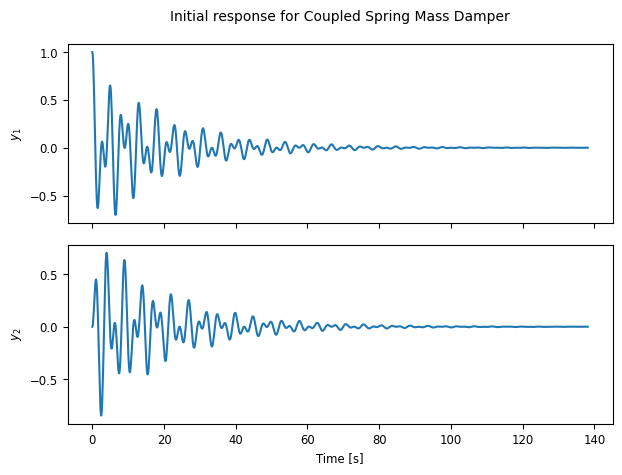

In [3]:
# start from a given initial condition to note the initial response 
response = ct.initial_response(sys, X0=[1,0,0,0])
cplt = response.plot()

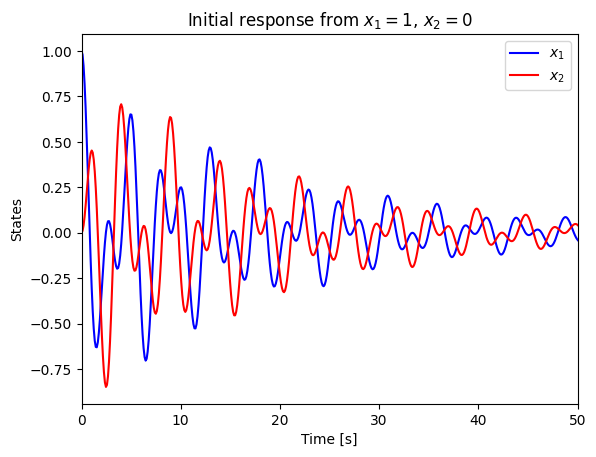

In [4]:
# plot the outputs of the system on the same graph, in different color 
t = response.time 
x = response.states 
plt.plot(t, x[0], 'b', t, x[1], 'r')
plt.legend(['$x_1$', '$x_2$'])
plt.xlim(0, 50)
plt.ylabel('States')
plt.xlabel('Time [s]')
plt.title("Initial response from $x_1=1$, $x_2=0$"); 

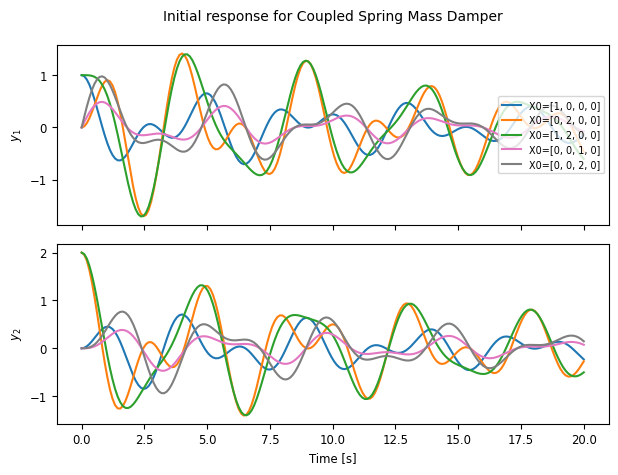

In [5]:
# plots for multiple initial responses 
for X0 in [[1,0,0,0], [0,2,0,0], [1,2,0,0], [0,0,1,0], [0,0,2,0]]: 
    response = ct.initial_response(sys, T=20, X0=X0)
    response.plot(label=f"{X0=}")

## Step response 

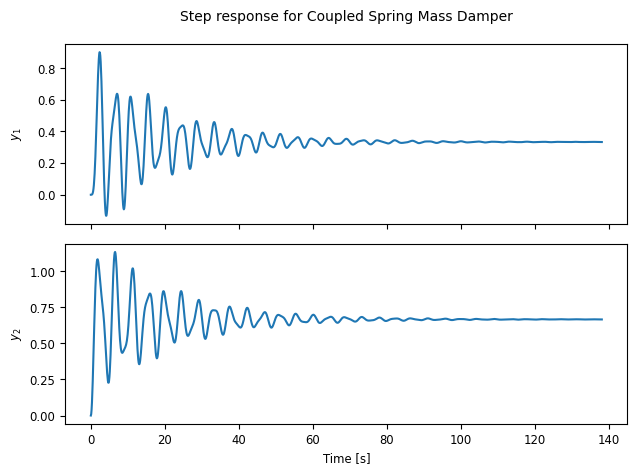

In [6]:
cplt = ct.step_response(sys).plot() 
# plot inputs as well: cplt = ct.step_response(sys).plot(plot_inputs=True)
# plot inputs on the top of outputs: cplt = ct.step_response(sys).plot(plot_inputs='overlay)

In [7]:
step_info = ct.step_info(sys)
step_info

[[{'RiseTime': 0.615390225299077,
   'SettlingTime': 89.02645259326647,
   'SettlingMin': -0.1327284565536944,
   'SettlingMax': 0.9005994876222034,
   'Overshoot': 170.17984628666105,
   'Undershoot': 39.81853696610832,
   'Peak': 0.9005994876222034,
   'PeakTime': 2.3589958636464616,
   'SteadyStateValue': 0.3333333333333333}],
 [{'RiseTime': 0.6153902252990769,
   'SettlingTime': 73.64169696078955,
   'SettlingMin': 0.22760198207822405,
   'SettlingMax': 1.1338933771021502,
   'Overshoot': 70.08400656532254,
   'Undershoot': 0.0,
   'Peak': 1.1338933771021502,
   'PeakTime': 6.564162403190155,
   'SteadyStateValue': 0.6666666666666666}]]

In [8]:
# Look at the "shape" of the step response
stepresp = ct.step_response(sys)
print(f"{stepresp.time.shape=}")
print(f"{stepresp.inputs.shape=}")
print(f"{stepresp.states.shape=}")
print(f"{stepresp.outputs.shape=}")

stepresp.time.shape=(1348,)
stepresp.inputs.shape=(1, 1, 1348)
stepresp.states.shape=(4, 1, 1348)
stepresp.outputs.shape=(2, 1, 1348)


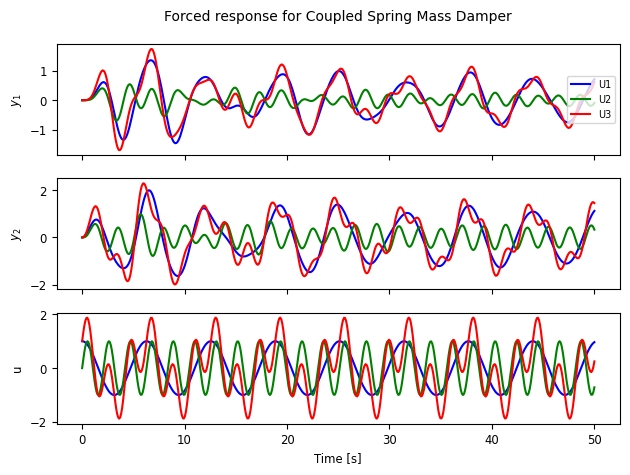

In [9]:
# Forced response 
T = np.linspace(0, 50, 500) 
U1 = np.cos(T)
U2 = np.sin(3*T)

resp1 = ct.forced_response(sys, T, U1)
resp2 = ct.forced_response(sys, T, U2)
resp3 = ct.forced_response(sys, T, U1 + U2)

# Plot the individual responses 
resp1.sysname = 'U1'; resp1.plot(color='b')
resp2.sysname = 'U2'; resp2.plot(color='g')
resp3.sysname = 'U3'; resp3.plot(color='r')

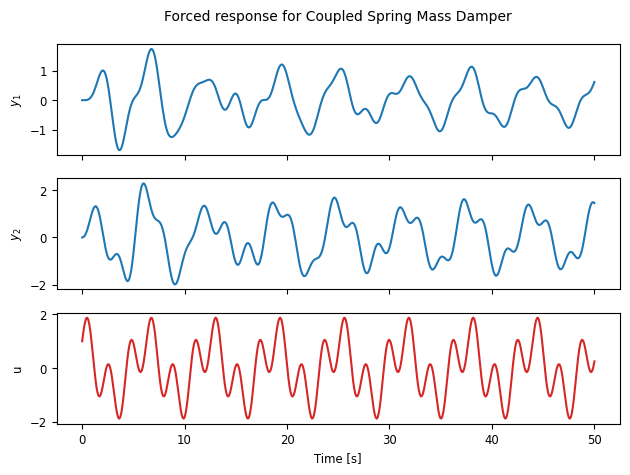

In [10]:
# show that the system response is linear 
cplt = resp3.plot(label="G(U1 + U2)")

## Frequency Response 

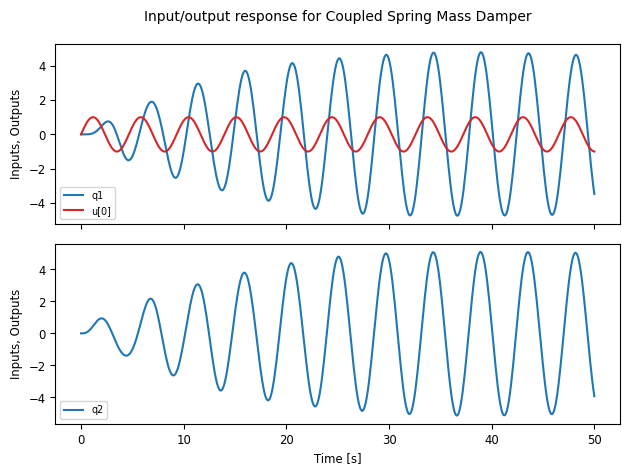

In [11]:
# manually compute the frequency response 
resp = ct.input_output_response(sys, T, np.sin(1.35*T))

cplt = resp.plot(
    plot_inputs='overlay', 
    legend_map=np.array([['lower left'], ['lower left']]), 
    label=[['q1', 'u[0]'], ['q2', None]])

In [12]:
G = ct.ss2tf(sys, name='u to q1 q2')
print(G)

<TransferFunction>: u to q1 q2
Inputs (1): ['u']
Outputs (2): ['$y_1$', '$y_2$']

Input 1 to output 1:

    -5.551e-17 s^3 + 3.331e-16 s + 4
  -------------------------------------
  s^4 + 0.2 s^3 + 8.01 s^2 + 0.8 s + 12

Input 1 to output 2:

   -3.886e-16 s^3 + 2 s^2 + 0.2 s + 8
  -------------------------------------
  s^4 + 0.2 s^3 + 8.01 s^2 + 0.8 s + 12


In [13]:
np.absolute(G(0))

array([[0.33333333],
       [0.66666667]])

In [14]:
# gain and phase for simulation above 
# Gain: How much the system amplifies/attenuates a sinusoidal input at this frequency 
# Phase: How much the system shifts the phase of the input sinusoid.
from math import pi 
val = G(1.35j)
print(f"{G(1.35j)=}")
print(f"Gain: {np.absolute(val)}")
print(f"Phase: {np.angle(val)} radians", "OR", np.angle(val) * 180/pi, "deg)")

G(1.35j)=array([[3.33005647-2.70686327j],
       [3.80831226-2.72231858j]])
Gain: [[4.29143157]
 [4.681267  ]]
Phase: [[-0.6825322 ]
 [-0.62061375]] radians OR [[-39.10621449]
 [-35.55854848]] deg)


In [15]:
# gain and phase at s = 0 (= steady state response)
print(f"{G(0)=}")
print("Final value of step response:", stepresp.outputs[0,0,-1])

G(0)=array([[0.33333333+0.j],
       [0.66666667+0.j]])
Final value of step response: 0.3329754181372488


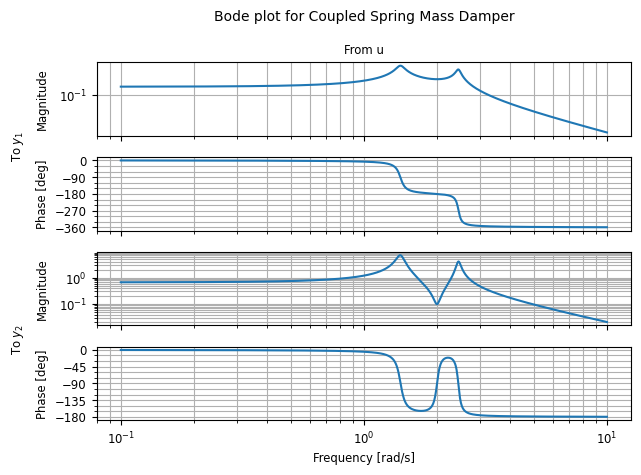

In [16]:
# frequency response across all frequencies 
freqresp = ct.frequency_response(sys)
cplt = freqresp.plot()

/Users/sohamprajapati/Documents/hb_srp/Efficient Grid/vica/.venv/lib/python3.11/site-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


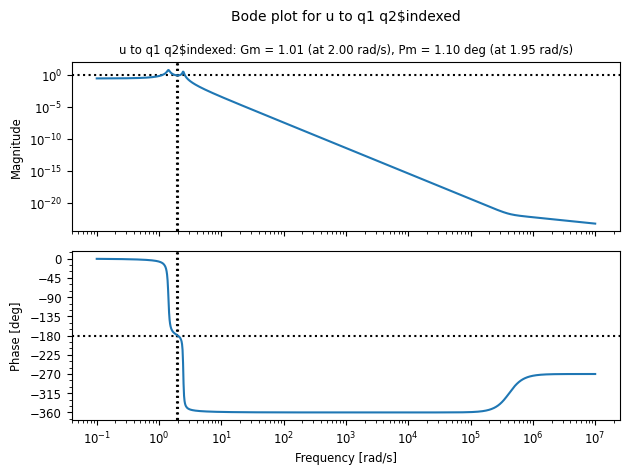

In [17]:
cplt = ct.bode_plot(G[0,0], overlay_outputs=True, display_margins=True)

/Users/sohamprajapati/Documents/hb_srp/Efficient Grid/vica/.venv/lib/python3.11/site-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


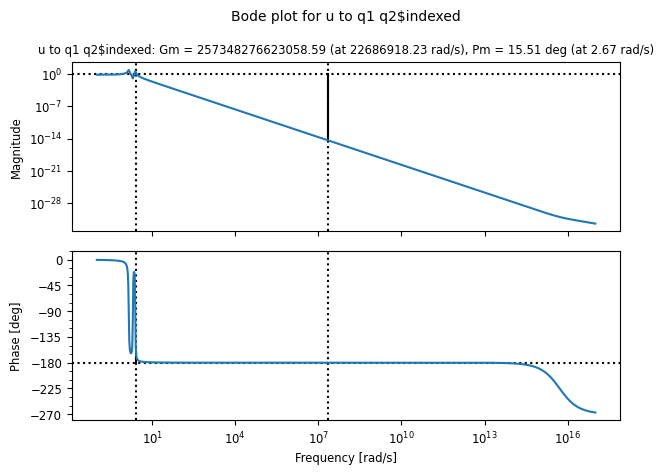

In [18]:
ctplt2 = ct.bode_plot(G[1,0], overlay_outputs=True, display_margins=True)


## Example 2: Revisiting the GM and PM 

In [21]:
from sympy import symbols, expand 
s = symbols('s')
den = expand(s*(s+2)*(s+5))
den

s**3 + 7*s**2 + 10*s

In [ ]:
import control as ct 

G = ct.tf([100.], [1., 7., 10., 0.])
print(G)


<TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         100
  ------------------
  s^3 + 7 s^2 + 10 s


In [28]:
gm, pm, wgc, wpc = ct.margin(G)
gm, pm, wgc, wpc 

(np.float64(0.7000000000000001),
 np.float64(-8.891243129606409),
 np.float64(3.1622776601683795),
 np.float64(3.7568670450279327))

## Example 3: Trajectory Tracking for Kinematic Vecicle Model 

In [36]:
from sympy import symbols, cos, sin, tan, atan2, Matrix, simplify
from IPython.display import display, Math

# Define symbolic variables
# States
x, y, theta = symbols('x y theta')

# Inputs
v, delta = symbols('v delta')

# Parameters
a, b = symbols('a b', positive=True, real=True)  # refoffset, wheelbase

# Compute alpha (angle between heading and velocity at center of mass)
alpha = atan2(a * tan(delta), b)

# State vector
state = Matrix([x, y, theta])

# State derivatives (the nonlinear dynamics)
x_dot = v * cos(theta + alpha)
y_dot = v * sin(theta + alpha)
theta_dot = (v / a) * sin(alpha)

# State derivative vector
state_dot = Matrix([x_dot, y_dot, theta_dot])

print("Vehicle Kinematic Model - Nonlinear Equations")
print("=" * 60)
print("\nState vector:")
print(f"x = {state.T}")

print("\nInput vector:")
print(f"u = [v, δ]ᵀ")

print("\nParameters:")
print(f"a = reference offset (distance from rear axle to center of mass)")
print(f"b = wheelbase (distance from rear axle to front axle)")

print("\n" + "=" * 60)
print("\nAuxiliary angle (slip angle at center of mass):")
print(f"α = atan2(a·tan(δ), b)")

print("\n" + "=" * 60)
print("\nState dynamics: ẋ = f(x, u)")
print("\nẋ = v·cos(θ + α)")
print("ẏ = v·sin(θ + α)")
print("θ̇ = (v/a)·sin(α)")

print("\n" + "=" * 60)
print("\nIn vector form:")
print("     ⎡ẋ⎤   ⎡v·cos(θ + α)    ⎤")
print("ẋ =  ⎢ẏ⎥ = ⎢v·sin(θ + α)    ⎥")
print("     ⎣θ̇⎦   ⎣(v/a)·sin(α)    ⎦")

print("\n" + "=" * 60)
print("\nOutput equation: y = h(x, u)")
print("y = x  (full state feedback)")

# Create the Jacobians for linearization around operating points
print("\n" + "=" * 60)
print("\nJacobians (for linearization):")

# Jacobian with respect to states
A_sym = state_dot.jacobian(state)
print("\nA = ∂f/∂x:")
display(A_sym)

# Jacobian with respect to inputs
B_sym = state_dot.jacobian(Matrix([v, delta]))
print("\nB = ∂f/∂u:")
display(B_sym)

print("\n" + "=" * 60)
print("\nNote: For linearization around a trajectory (x̄, ū),")
print("substitute the nominal values into A and B to get")
print("the linear time-varying approximation:")
print("δẋ ≈ A(t)·δx + B(t)·δu")

Vehicle Kinematic Model - Nonlinear Equations

State vector:
x = Matrix([[x, y, theta]])

Input vector:
u = [v, δ]ᵀ

Parameters:
a = reference offset (distance from rear axle to center of mass)
b = wheelbase (distance from rear axle to front axle)


Auxiliary angle (slip angle at center of mass):
α = atan2(a·tan(δ), b)


State dynamics: ẋ = f(x, u)

ẋ = v·cos(θ + α)
ẏ = v·sin(θ + α)
θ̇ = (v/a)·sin(α)


In vector form:
     ⎡ẋ⎤   ⎡v·cos(θ + α)    ⎤
ẋ =  ⎢ẏ⎥ = ⎢v·sin(θ + α)    ⎥
     ⎣θ̇⎦   ⎣(v/a)·sin(α)    ⎦


Output equation: y = h(x, u)
y = x  (full state feedback)


Jacobians (for linearization):

A = ∂f/∂x:


Matrix([
[0, 0, -v*sin(theta + atan2(a*tan(delta), b))],
[0, 0,  v*cos(theta + atan2(a*tan(delta), b))],
[0, 0,                                      0]])


B = ∂f/∂u:


Matrix([
[       cos(theta + atan2(a*tan(delta), b)),                                                 -a*b*v*(tan(delta)**2 + 1)*sin(theta + atan2(a*tan(delta), b))/(a**2*tan(delta)**2 + b**2)],
[       sin(theta + atan2(a*tan(delta), b)),                                                  a*b*v*(tan(delta)**2 + 1)*cos(theta + atan2(a*tan(delta), b))/(a**2*tan(delta)**2 + b**2)],
[tan(delta)/sqrt(a**2*tan(delta)**2 + b**2), -a**2*v*(2*tan(delta)**2 + 2)*tan(delta)**2/(2*(a**2*tan(delta)**2 + b**2)**(3/2)) + v*(tan(delta)**2 + 1)/sqrt(a**2*tan(delta)**2 + b**2)]])



Note: For linearization around a trajectory (x̄, ū),
substitute the nominal values into A and B to get
the linear time-varying approximation:
δẋ ≈ A(t)·δx + B(t)·δu


In [ ]:
# define the update rule for the system, 
# f(x, u)
# States: x, y, theta (position and angle of the center of mass)
# Inputs: v (forward velocity), delta (steering angle)
def vehicle_update(t, x, u, params):
    # get the model parameters 
    a = params.get('refoffset', 1.5) # offset to vehicle reference point: how much the rear axle of the car is from the center of mass
    b = params.get('wheelbase', 3.0) # vehicle wheelbase: distance between the front wheels and rear wheels. 
    maxsteer = params.get('maxsteer', 0.5)

    # saturate the steering input 
    delta = np.clip(u[1], -maxsteer, maxsteer)
    alpha = np.arctan2(a * np.tan(delta), b) # this represents the angle between the vehicle's heading and the velocity vector at the center of mass. 
    # When you steer the front wheels by angle delta, the COM doesn't move in the direction the wheels point -- it moves slightly different angle because it's offset from the wheels. 

    # return the derivate of the state 
    return np.array([
        u[0] * np.cos(x[2] + alpha), # xdot = cos(theta + alpha) v
        u[0] * np.sin(x[2] + alpha), # ydot = sin(theta + alpha) v
        (u[0] / a) * np.sin(alpha)   # thdot = v sin(alpha) / a
    ])

# define the readout map for the system, h(x, u) 
# outputs: x, y (planar position of the center of mass)
def vehicle_output(t, x, u, params): 
    return x 

# default vehicle parameters 
vehicle_params={'refoffset': 1.5, 'wheelbase': 3, 'velocity': 15, 'maxsteer': 0.5}

# define the vehicle steering dynamics as an input/output system 
vehicle = ct.nlsys(
    vehicle_update, vehicle_output, states=3, name='vehicle', inputs=['v', 'delta'], outputs=['x', 'y', 'theta'], params=vehicle_params
)

In [30]:
# open loop simulation 

# define the time interval that we want to use for the simulation 
timepts = np.linspace(0,10,1000) 

# define the inputs 
U = [
    10 * np.ones_like(timepts), 
    0.1 * np.sin(timepts * 2 * np.pi)
]

# simulate the system dynamics, starting from the origin  
response = ct.input_output_response(vehicle, timepts, U, 0)
time, outputs, inputs = response.time, response.outputs, response.inputs 

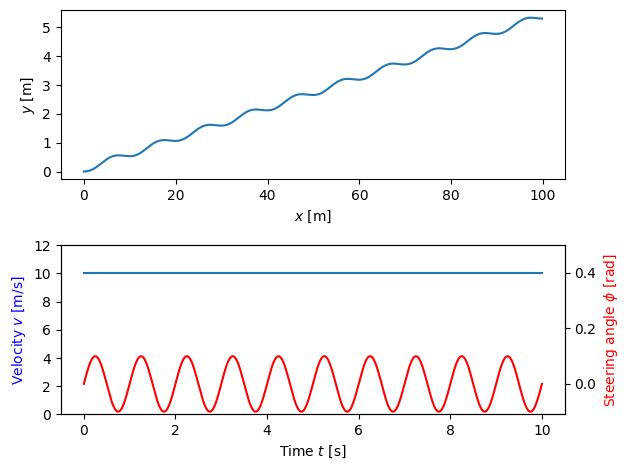

In [31]:
# Create a figure to plot the results
fig, ax = plt.subplots(2, 1)

# Plot the results in the xy plane
ax[0].plot(outputs[0], outputs[1])
ax[0].set_xlabel("$x$ [m]")
ax[0].set_ylabel("$y$ [m]")

# Plot the inputs
ax[1].plot(timepts, U[0])
ax[1].set_ylim(0, 12)
ax[1].set_xlabel("Time $t$ [s]")
ax[1].set_ylabel("Velocity $v$ [m/s]")
ax[1].yaxis.label.set_color('blue')

rightax = ax[1].twinx()       # Create an axis in the right
rightax.plot(timepts, U[1], color='red')
rightax.set_ylim(None, 0.5)
rightax.set_ylabel(r"Steering angle $\phi$ [rad]")
rightax.yaxis.label.set_color('red')

fig.tight_layout()

In [50]:
# desired trajectory 
Ud = np.array([10 * np.ones_like(timepts), np.zeros_like(timepts)])
Xd = np.array([10 * timepts, 0 * timepts, np.zeros_like(timepts)])

# now linearize the system around this trajectory 
linsys = vehicle.linearize(Xd[:, 0], Ud[:, 0])

In [ ]:
# check the eigenvalues of the open loop system 
np.linalg.eigvals(linsys.A)
# we see that all values are zero, corresponding to a single integrator in the x (longitudinal) direction 
# and a double integrator in the y (lateral) direction. 

array([0., 0., 0.])